# All necessary pre-requisite imports

In [1]:
import re
import random
import math
import time
from collections import Counter


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.metrics.pairwise import cosine_similarity

#Helping functions necessary library
import nltk
import spacy
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from spacy.lang.en.stop_words import STOP_WORDS
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

#Semantic Embeddings
!pip install gensim
from gensim.models import Word2Vec

#PCA visualization
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

#Fine tuning pre-requisite
!pip install -q transformers datasets accelerate

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

try:
    from IPython.display import display
except Exception:
    display = print

random.seed(42)
np.random.seed(42)

pd.set_option("display.max_colwidth", 140)

def display_table(data, title=None):
    if title:
        print(title)
    display(data)

from google.colab import drive
drive.mount('/content/drive')

print("Environment setup completed successfully.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment setup completed successfully.


# Task 1 - Preprocessing and Exploratory Analysis for Customer Feedback Inputs

# Loading Dataset

In [2]:
df_original = pd.read_csv('/content/drive/MyDrive/sem2 assignments/nlp assignment/dataset file/complaints_processed.csv', sep=',')

if 'ticket_id,category,text' in df_original.columns:
    df_original[['ticket_id', 'category', 'text']] = df_original['ticket_id,category,text'].str.split(',', n=2, expand=True)
    df = df_original.drop(columns=['ticket_id,category,text'])

df = df[['ticket_id', 'text', 'category']]
df_copy = df.copy()

display_table(df_copy.head(10), title= 'Complaint Classification Dataset')

Complaint Classification Dataset


,ticket_id,text,category
0,0,purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company ...,credit_card
1,1,forwarded message date tue subject please investigate comenity bank retailer card scam sent hello name scammed comenity bank credit card...,credit_card
2,2,forwarded message cc sent friday pdt subject final legal payment well fargo well fargo clearly wrong need look actually opened account s...,retail_banking
3,3,payment history missing credit report specialized loan servicing sl made mistake put account forbearance without authorization knowledge...,credit_reporting
4,4,payment history missing credit report made mistake put account forbearance without authorization knowledge matter fact automatic payment...,credit_reporting
5,5,payment history missing credit report made mistake put account forbearance without authorization knowledge matter fact automatic payment...,credit_reporting
6,6,va date complaint experian credit bureau involved decision maker stop cease retaliation discrimination abuse american taxpayer today exp...,credit_reporting
7,7,account reported abbreviated name full name servicer account transunion reporting date last payment reporting payment due account time h...,credit_reporting
8,8,account reported abbreviated name full name servicer account experian reporting date last payment reporting payment due account time how...,credit_reporting
9,9,usdoexxxx account reported abbreviated name full name servicer account reporting date last payment equifax reporting payment due account...,credit_reporting


# Describing the dataset


In [3]:
print(df_copy.shape)

print('\nColumn names: ')
print(df_copy.columns.tolist())

print('\nData types: ')
display(df_copy.dtypes.to_frame(name='Data Type'))

print('\nMissing values: ')
print(df_copy.isna().sum().to_frame(name='Missing Values'))

print('\nNumber of duplicate rows: ',df_copy.duplicated().sum())

display(df_copy.describe())

(162421, 3)

Column names: 
['ticket_id', 'text', 'category']

Data types: 


,Data Type
ticket_id,object
text,object
category,object



Missing values: 
           Missing Values
ticket_id               0
text                    0
category                0

Number of duplicate rows:  0


,ticket_id,text,category
count,162421,162421,162421
unique,162421,124473,5
top,162420,victim identity notified collection creditor several time account belong way received good service company provided police report ftc id...,credit_reporting
freq,1,739,91179


# Exploratory *Visualisations*

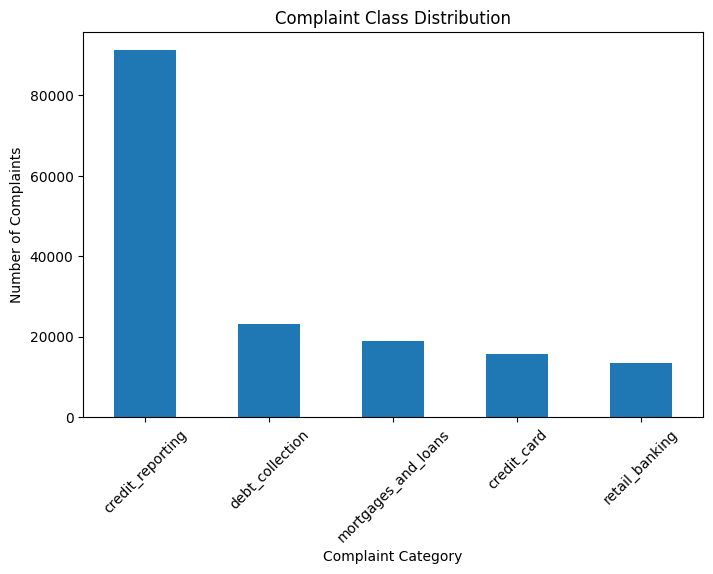

In [4]:
#Complaint Class Distribution
df['category'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Complaint Class Distribution")
plt.xlabel("Complaint Category")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.show()

# Helping Functions used for cleaning and preprocessing

In [5]:
nlp = spacy.load("en_core_web_sm")

#Token Counter
def token_counter(tokens):
    token_count = Counter(tokens)

    return token_count

#Cleaning Raw Text
def clean_raw_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

#Creating Tokens
def create_tokens(text):
    text = clean_raw_text(text)
    tokens = text.split()

    return tokens

#Creating Tokens with nltk
def create_tokens_with_nltk(text):
    text = clean_raw_text(text)
    tokens = word_tokenize(text)

    return tokens

#Creating Tokens with spacy
def create_tokens_with_spacy(text):
    text = clean_raw_text(text)
    text_sp = nlp(text)
    tokens = [token.text for token in text_sp]

    return tokens

#Negated words
negated_words = set(["no","not","never","nor","none","neither","nothing","nobody","no one","nowhere","hardly","barely","scarcely","without","cannot",
                     "can't","won't","don't","doesn't","didn't","isn't","aren't","wasn't","weren't","hasn't","haven't","hadn't","shouldn't","wouldn't","couldn't","mustn't","needn't","mightn't","shan't"])

#Removing Connecting Words with nltk
stop_words = set(stopwords.words('english'))
stop_words = stop_words - negated_words

def remove_conectors_with_nltk(tokens):
    tokens = [token for token in tokens if token not in stop_words]

    return tokens

#Removing Connecting Words with spacy
stop_words = STOP_WORDS - negated_words

def remove_conectors_with_spacy(tokens):
    return [token for token in tokens if token.lower() not in stop_words]

#Lemmatizing the tokens with nltk
lemmatizer = WordNetLemmatizer()
def lemmatize_with_nltk(tokens):
    lemma_table = pd.DataFrame({
      'Word': tokens,
      'Lemma': [lemmatizer.lemmatize(token) for token in tokens],
      'Lemma as verb': [lemmatizer.lemmatize(token, pos='v') for token in tokens]
    })

    return display_table(lemma_table, title='Lemmatizing the tokens with nltk')

#Lemmatizing the tokens with spacy
def lemmatize_with_spacy(text):
    text_sp = nlp(text)
    lemma_table = pd.DataFrame({
        "Word": [text.text for text in text_sp],
        "Lemma": [text.lemma_ for text in text_sp],
    })

    return display_table(lemma_table, title = 'Lemmatizing the tokens with spacy')

#Lemmatizing function with nltk for not display
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token, pos='v') for token in tokens]


#Entity Recognition
def entity_recognition(text):
    text_sp = nlp(text)
    entities = [{"Entity": ent.text, "Label": ent.label_} for ent in text_sp.ents]

    return display_table(pd.DataFrame(entities), title = 'Entity Recognition')

# Comparision between nltk & spacy

In [6]:
#Preprocessing using nltk
print('Preprocessing using nltk')
print('\n')
text_nltk = clean_raw_text(df_copy['text'][0])
tokens_nltk = create_tokens_with_nltk(text_nltk)
nltk_token_counter = token_counter(tokens_nltk)
print('Token Counter', nltk_token_counter)
vocabulary = sorted([word for word in nltk_token_counter.keys()])
vocabulary_size = len(vocabulary)
print('Vocabulary size:', vocabulary_size)
print('\n')
tokens_nltk = remove_conectors_with_nltk(tokens_nltk)
lemmatize_with_nltk(tokens_nltk)

print('\n')

#Preprocessing using spacy
print('Preprocessing using spacy')
print('\n')
text_spacy = clean_raw_text(df_copy['text'][0])
tokens_spacy = create_tokens_with_spacy(text_spacy)
spacy_token_counter = token_counter(tokens_spacy)
print('Token Counter', spacy_token_counter)
vocabulary = sorted([word for word in spacy_token_counter.keys()])
vocabulary_size = len(vocabulary)
print('Vocabulary size:', vocabulary_size)
print('\n')
tokens_spacy = remove_conectors_with_spacy(tokens_spacy)
lemmatize_with_spacy(text_spacy)

print('\n')

#Entity Recognition
print('Entity Recognition')
print('\n')
entity_recognition(text_spacy)

Preprocessing using nltk


Token Counter Counter({'order': 13, 'purchase': 5, 'shipping': 5, 'purchased': 5, 'amount': 4, 'canceled': 4, 'called': 4, 'transaction': 4, 'case': 4, 'due': 3, 'cancel': 3, 'refund': 3, 'stated': 3, 'posted': 3, 'appears': 3, 'statement': 3, 'capital': 3, 'one': 3, 'day': 2, 'receive': 2, 'product': 2, 'week': 2, 'sent': 2, 'email': 2, 'exact': 2, 'high': 2, 'stock': 2, 'place': 2, 'soon': 2, 'u': 2, 'first': 2, 'requested': 2, 'refunded': 2, 'item': 2, 'visa': 2, 'submitted': 2, 'back': 2, 'dispute': 2, 'rebillmerchandiserobert': 2, 'ca': 2, 'thu': 2, 'rebill': 2, 'manager': 2, 'ruled': 2, 'favor': 2, 'removed': 2, 'j': 2, 'followup': 1, 'verbiage': 1, 'paid': 1, 'two': 1, 'received': 1, 'company': 1, 'responded': 1, 'im': 1, 'sorry': 1, 'inform': 1, 'unusually': 1, 'volume': 1, 'shipped': 1, 'several': 1, 'since': 1, 'early': 1, 'demand': 1, 'although': 1, 'continuing': 1, 'take': 1, 'guaranteeing': 1, 'time': 1, 'mask': 1, 'date': 1, 'right': 1, 'however

,Word,Lemma,Lemma as verb
0,purchase,purchase,purchase
1,order,order,order
2,day,day,day
3,shipping,shipping,ship
4,receive,receive,receive
...,...,...,...
199,knew,knew,know
200,case,case,case
201,manager,manager,manager
202,ruling,ruling,rule




Preprocessing using spacy


Token Counter Counter({'order': 13, 'purchase': 5, 'shipping': 5, 'purchased': 5, 'amount': 4, 'canceled': 4, 'called': 4, 'transaction': 4, 'case': 4, 'due': 3, 'cancel': 3, 'refund': 3, 'stated': 3, 'posted': 3, 'appears': 3, 'statement': 3, 'capital': 3, 'one': 3, 'day': 2, 'receive': 2, 'product': 2, 'week': 2, 'sent': 2, 'email': 2, 'exact': 2, 'high': 2, 'stock': 2, 'place': 2, 'soon': 2, 'u': 2, 'first': 2, 'requested': 2, 'refunded': 2, 'item': 2, 'visa': 2, 'submitted': 2, 'back': 2, 'dispute': 2, 'rebillmerchandiserobert': 2, 'ca': 2, 'thu': 2, 'rebill': 2, 'manager': 2, 'ruled': 2, 'favor': 2, 'removed': 2, 'j': 2, 'followup': 1, 'verbiage': 1, 'paid': 1, 'two': 1, 'received': 1, 'company': 1, 'responded': 1, 'i': 1, 'm': 1, 'sorry': 1, 'inform': 1, 'unusually': 1, 'volume': 1, 'shipped': 1, 'several': 1, 'since': 1, 'early': 1, 'demand': 1, 'although': 1, 'continuing': 1, 'take': 1, 'guaranteeing': 1, 'time': 1, 'mask': 1, 'date': 1, 'right': 1

,Word,Lemma
0,purchase,purchase
1,order,order
2,day,day
3,shipping,shipping
4,amount,amount
...,...,...
227,anything,anything
228,case,case
229,manager,manager
230,ruling,ruling




Entity Recognition


Entity Recognition


,Entity,Label
0,order day,DATE
1,two day,DATE
2,several week,DATE
3,first,ORDINAL
4,first,ORDINAL
5,mon,PERSON


In [7]:
comparison_nltk_and_spacy = pd.DataFrame({
    "Feature": [
        "Token Count",
        "Vocabulary Size",
        "NER",
        "Lemmatization",
        "Speed",
        "Pipeline"
    ],
    "NLTK": [
        len(tokens_nltk),
        len(nltk_token_counter),
        "Not built-in",
        "WordNetLemmatizer",
        "Slower",
        "Educational"
    ],
    "spaCy": [
        len(tokens_spacy),
        len(spacy_token_counter),
        "Built-in",
        "Context-aware",
        "Faster",
        "Production"
    ]
})

display_table(comparison_nltk_and_spacy, title = 'Comparision table for nltk and spacy')

Comparision table for nltk and spacy


,Feature,NLTK,spaCy
0,Token Count,204,204
1,Vocabulary Size,144,146
2,NER,Not built-in,Built-in
3,Lemmatization,WordNetLemmatizer,Context-aware
4,Speed,Slower,Faster
5,Pipeline,Educational,Production


# Task 2 - Classical NLP Baseline for Complaint Classification

In [8]:
#Pre-Processing the data before training
df_copy["text_after_preprocessing"] = (
    df_copy["text"]
    .apply(clean_raw_text)
    .apply(create_tokens_with_nltk)
    .apply(remove_conectors_with_nltk)
    .apply(lemmatize_tokens)
    .apply(lambda tokens: " ".join(tokens))
)

#Splitting the data
X_Train, X_Test, y_Train, y_Test = train_test_split(
    df_copy["text_after_preprocessing"],
    df_copy['category'],
    test_size = 0.30,
    random_state = 42,
    stratify = df_copy['category'])

# Combine training text and labels
train_data = pd.DataFrame({
    "text": X_Train.values,
    "category": y_Train.values
})

# Find the size of the smallest class
min_class_size = train_data["category"].value_counts().min()

# Undersample each class to the smallest class size
balanced_train_data = pd.concat([
    resample(
        df_copy[df_copy["category"] == category],
        replace=False,
        n_samples=min_class_size,
        random_state=42
    )
    for category in train_data["category"].unique()
])

# Shuffle the balanced data
balanced_train_data = balanced_train_data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

X_Train = balanced_train_data["text"]
y_Train = balanced_train_data["category"]

print("Class Distribution AFTER Balancing:")
display(y_Train.value_counts())

Class Distribution AFTER Balancing:


,count
category,
credit_reporting,9475
mortgages_and_loans,9475
retail_banking,9475
credit_card,9475
debt_collection,9475


In [9]:
#Model Pipeline
LR_model = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range = (1,2))),
    ('classifier', LogisticRegression(class_weight="balanced",max_iter=1000))
])

#Training the model
LR_model.fit(X_Train, y_Train)

#Predicting the results
y_pred = LR_model.predict(X_Test)


#Evaluation metrics
print('Classification Report: ')
print(classification_report(y_Test, y_pred, zero_division=0))
print('\n')
print('Confusion Matrix: ')
print(confusion_matrix(y_Test, y_pred))
print('\n')
print("Accuracy score: ")
print("Accuracy:", accuracy_score(y_Test, y_pred))

Classification Report: 
                     precision    recall  f1-score   support

        credit_card       0.71      0.81      0.76      4670
   credit_reporting       0.96      0.81      0.88     27354
    debt_collection       0.68      0.83      0.75      6945
mortgages_and_loans       0.73      0.90      0.80      5697
     retail_banking       0.79      0.93      0.85      4061

           accuracy                           0.83     48727
          macro avg       0.77      0.86      0.81     48727
       weighted avg       0.85      0.83      0.84     48727



Confusion Matrix: 
[[ 3798   214   113   115   430]
 [ 1006 22229  2411  1421   287]
 [  230   542  5736   323   114]
 [  104   196   130  5127   140]
 [  203    16    25    60  3757]]


Accuracy score: 
Accuracy: 0.8341781763703902


# Visualization of Confusion Matrix

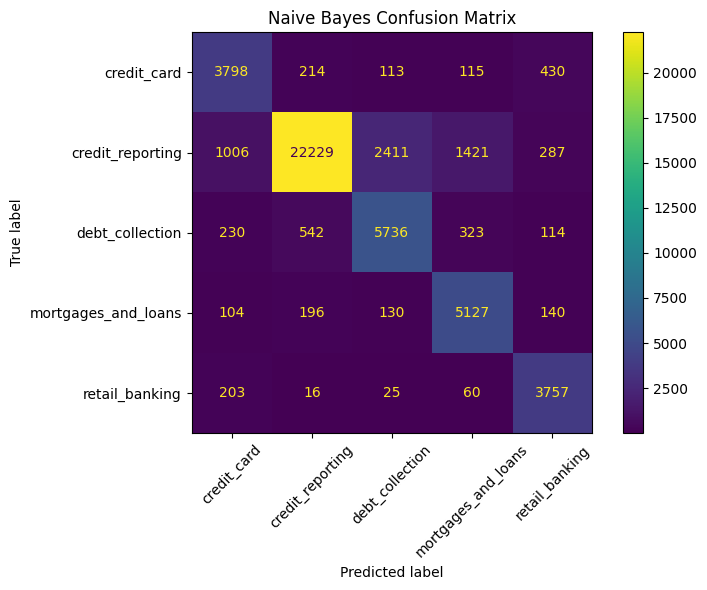

In [10]:
labels = sorted(df_copy['category'].unique())

cm = confusion_matrix(y_Test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(8,6))
cm_fig = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

cm_fig.plot(ax=ax, xticks_rotation=45)
plt.title("Naive Bayes Confusion Matrix")
plt.tight_layout()
plt.show()

# Error Analysis Table

In [11]:
#Error Analysis Table
error_analysis_df = pd.DataFrame({
    'Text': X_Test.values,
    'True category': y_Test.values,
    'Predicted category': y_pred,
    'confidence': LR_model.predict_proba(X_Test).max(axis=1)
})

error_analysis_df['Correct'] = error_analysis_df['True category'] == error_analysis_df['Predicted category']
display_table(error_analysis_df, "Prediction-level error analysis: ")

Prediction-level error analysis: 


,Text,True category,Predicted category,confidence,Correct
0,husband direct pay account loan company automatically withdraw account month far half year problem loan company u year account loan comp...,mortgages_and_loans,mortgages_and_loans,0.897627,True
1,pay debt directly hospital never cmre report minor son bill credit report attach receipt pay hospital account cmre account,debt_collection,debt_collection,0.890529,True
2,shellpoint mortgage company mortgage forbarance hight pandemic without permition raise mortgage rate month without inform verbal communi...,credit_reporting,mortgages_and_loans,0.959132,False
3,car loan pay early make large payment month addition monthly payment experian credit report late payment report incorrect reach experian...,credit_reporting,credit_reporting,0.996069,True
4,check credit report notice midwest recovery credit report obtain number conduct research obtain address follow mo dispute debt past appe...,credit_reporting,debt_collection,0.821699,False
...,...,...,...,...,...
48722,process home need pay debt deal escrow company send payment debtor loan process debtor dci owe old speak dci payment arrangement settle ...,debt_collection,mortgages_and_loans,0.586832,False
48723,car business report late never miss payment begin remove late payment account,mortgages_and_loans,credit_reporting,0.491743,False
48724,american express continue break fdcpa law establish debt collection balance past american express call cell phone home phone sunday lega...,debt_collection,debt_collection,0.729761,True
48725,send ftc experian non account xxxxdispute xxxxdispute xxxxdispute xxxxdispute xxxxdispute xxxxdispute xxxxdispute,credit_reporting,credit_reporting,0.788589,True


# Task 3 - Semantic Embeddings for Feedback Retrieval and Similarity Analysis

Loading genism and training our model on word2vec as we have lot of data on complaints to train

In [12]:
#Processing the text for word2vec
df_copy["text_after_preprocessing"] = (
    df_copy["text"]
    .apply(clean_raw_text)
    .apply(create_tokens_with_nltk)
    .apply(remove_conectors_with_nltk)
    .apply(lemmatize_tokens)
)

In [13]:
#Training the word2vec model with the selected dataset
word2vec_model = Word2Vec(
    sentences = df_copy["text_after_preprocessing"],
    vector_size = 150,
    window = 5,
    min_count = 2,
    workers = 4,
    sg = 1,
    epochs = 5
)

In [14]:
word2vec_model.wv.most_similar("credit", topn=10)

[('report', 0.7562737464904785),
 ('creidt', 0.6497818231582642),
 ('xxxxtransunion', 0.621145486831665),
 ('reoports', 0.6170380711555481),
 ('negativley', 0.6135937571525574),
 ('xxxxtotal', 0.613172173500061),
 ('xxxxedit', 0.609966516494751),
 ('aess', 0.6062547564506531),
 ('bueraus', 0.6049818396568298),
 ('definately', 0.6047028303146362)]

In [15]:
credit_vector = word2vec_model.wv["credit"]
report_vector = word2vec_model.wv["report"]

similarity = cosine_similarity(
    [credit_vector],
    [report_vector]
)[0][0]

print("Cosine similarity:", similarity)

Cosine similarity: 0.7562737


In [16]:
#Creating helper function for word vector to sentence vector
def get_sentence_vector(tokens, model):
    vectors = []

    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

#Converting every complaint to single vector of 150 dimensions
df_copy["sentence_vector"] = df_copy["text_after_preprocessing"].apply(
    lambda tokens: get_sentence_vector(tokens, word2vec_model)
)

In [17]:
print(df_copy["sentence_vector"].iloc[0])
print(len(df_copy["sentence_vector"].iloc[0]))

[ 9.16098356e-02 -7.33361347e-03 -1.26896679e-01  3.85298170e-02
  4.92705591e-02  5.95865771e-02  3.08889784e-02  2.10652083e-01
  2.67424384e-05 -1.77002121e-02  5.79011366e-02  2.41540335e-02
  2.72869617e-02  9.79311243e-02 -8.90246872e-03 -6.58006221e-03
 -1.79549024e-01 -9.68971699e-02  1.64120361e-01  1.66645974e-01
 -1.03579924e-01  1.31863534e-01  2.02426642e-01  5.30236587e-02
  1.41723722e-01 -1.64696991e-01  7.50995874e-02 -2.12887093e-01
  5.83836297e-03 -1.18899629e-01 -1.10872716e-01  4.66448143e-02
 -1.78897992e-01 -8.92514884e-02 -4.17149030e-02  1.34000361e-01
 -2.11750660e-02  6.58289194e-02  1.48151532e-01 -9.08012837e-02
  1.84449390e-01 -5.00019453e-03 -1.74687043e-01 -3.06541380e-02
  9.30734202e-02  1.33131072e-01  1.51944771e-01 -7.86079541e-02
  6.09584078e-02 -6.46825954e-02 -2.60124713e-01  1.01199247e-01
 -1.07480749e-01  1.31412789e-01 -8.27304348e-02  4.17973362e-02
 -1.78687051e-01  7.23295659e-02  1.96852535e-01  1.23677254e-01
  2.84632389e-02  8.79912

In [18]:
# Comparing two similar complaints using cosine similarity

complaint_A = "A debt I already paid is still showing on my credit report."
complaint_B = "My credit report has not been updated even though I have cleared the debt."

print("Complaint A:", complaint_A)
print("Complaint B:", complaint_B)

# Preprocess Complaint A
tokens_A = create_tokens_with_nltk(
    clean_raw_text(complaint_A)
)

tokens_A = remove_conectors_with_nltk(tokens_A)
tokens_A = lemmatize_tokens(tokens_A)

# Preprocess Complaint B
tokens_B = create_tokens_with_nltk(
    clean_raw_text(complaint_B)
)

tokens_B = remove_conectors_with_nltk(tokens_B)
tokens_B = lemmatize_tokens(tokens_B)

# Convert to sentence vectors
vector_A = get_sentence_vector(tokens_A, word2vec_model)
vector_B = get_sentence_vector(tokens_B, word2vec_model)

# Calculate cosine similarity
similarity = cosine_similarity(
    [vector_A],
    [vector_B]
)[0][0]

print("Cosine Similarity:", similarity)

Complaint A: A debt I already paid is still showing on my credit report.
Complaint B: My credit report has not been updated even though I have cleared the debt.
Cosine Similarity: 0.8950429


In [19]:
new_complaint = "My loan payment has not been correctly applied to my account."

#Preprocessing the new complaint
new_complaint_tokens = create_tokens_with_nltk(
    clean_raw_text(new_complaint)
)

new_complaint_tokens = remove_conectors_with_nltk(new_complaint_tokens)
new_complaint_tokens = lemmatize_tokens(new_complaint_tokens)

print(new_complaint_tokens)

['loan', 'payment', 'not', 'correctly', 'apply', 'account']


In [20]:
new_complaint_vectors = get_sentence_vector(
    new_complaint_tokens,
    word2vec_model
)

print(len(new_complaint_vectors))

150


In [21]:
df_copy["sentence_vector"]

all_vectors = np.vstack(
    df_copy["sentence_vector"].values
)

similarities = cosine_similarity(
    [new_complaint_vectors],
    all_vectors
)[0]

In [22]:
most_similar_index = np.argmax(similarities)
most_similar_complaint = df_copy.iloc[most_similar_index]

print("New complaint:")
print(new_complaint)

print("\nMost similar complaint:")
print(most_similar_complaint["text"])

print("\nCategory:")
print(most_similar_complaint["category"])

print("\nCosine similarity:")
print(similarities[most_similar_index])

New complaint:
My loan payment has not been correctly applied to my account.

Most similar complaint:
paid auto loan deferred payment payment incorrectly applied account

Category:
mortgages_and_loans

Cosine similarity:
0.9286655603327263


In [23]:
# Task 3 - PCA Visualization of Sentence Embeddings

# Convert sentence vectors into a 2D NumPy array
all_vectors = np.vstack(
    df_copy["sentence_vector"].values
)

print("Original embedding shape:", all_vectors.shape)

# Apply PCA
pca = PCA(n_components=2)

pca_embeddings = pca.fit_transform(all_vectors)

print("PCA embedding shape:", pca_embeddings.shape)

# Create PCA dataframe
pca_df = pd.DataFrame({
    "PC1": pca_embeddings[:, 0],
    "PC2": pca_embeddings[:, 1],
    "category": df_copy["category"].values
})

display(pca_df.head())

Original embedding shape: (162421, 150)
PCA embedding shape: (162421, 2)


,PC1,PC2,category
0,-0.448013,0.069100,credit_card
1,-0.293587,-0.039929,credit_card
2,-0.213770,0.109617,retail_banking
3,-0.304257,-0.155940,credit_reporting
4,-0.260427,-0.154794,credit_reporting


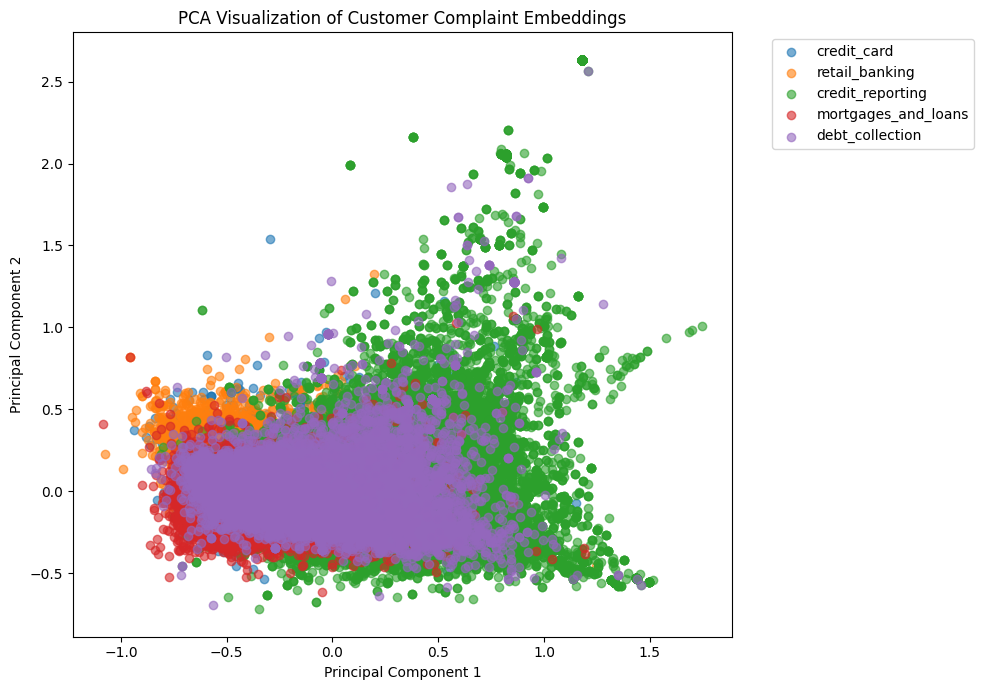

In [24]:
# Visualising the embeddings using PCA

plt.figure(figsize=(10, 7))

for category in pca_df["category"].unique():
    subset = pca_df[pca_df["category"] == category]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=category,
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Customer Complaint Embeddings")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#Task 4 - Fine Tuning a Transformer for Sentiment or Feedback Classification

In [25]:
# Select only the columns required for transformer training

transformer_df = df_copy[["text", "category"]].copy()

# Remove missing values
transformer_df = transformer_df.dropna(
    subset=["text", "category"]
)

# Remove duplicate complaints
transformer_df = transformer_df.drop_duplicates(
    subset=["text", "category"]
)

print("Total available examples:", len(transformer_df))

display(transformer_df.head())

Total available examples: 124679


,text,category
0,purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company ...,credit_card
1,forwarded message date tue subject please investigate comenity bank retailer card scam sent hello name scammed comenity bank credit card...,credit_card
2,forwarded message cc sent friday pdt subject final legal payment well fargo well fargo clearly wrong need look actually opened account s...,retail_banking
3,payment history missing credit report specialized loan servicing sl made mistake put account forbearance without authorization knowledge...,credit_reporting
4,payment history missing credit report made mistake put account forbearance without authorization knowledge matter fact automatic payment...,credit_reporting


In [26]:
# Select a manageable sample for Google Colab

SAMPLE_SIZE = 4000

if len(transformer_df) > SAMPLE_SIZE:
    transformer_df, _ = train_test_split(
        transformer_df,
        train_size=SAMPLE_SIZE,
        random_state=42,
        stratify=transformer_df["category"]
    )

transformer_df = transformer_df.reset_index(drop=True)

print("Transformer dataset size:", len(transformer_df))

print("\nClass distribution:")
print(transformer_df["category"].value_counts())

Transformer dataset size: 4000

Class distribution:
category
credit_reporting       1806
debt_collection         678
mortgages_and_loans     602
credit_card             482
retail_banking          432
Name: count, dtype: int64


In [27]:
# Create label mappings

categories = sorted(
    transformer_df["category"].unique()
)

label2id = {
    category: i
    for i, category in enumerate(categories)
}

id2label = {
    i: category
    for category, i in label2id.items()
}

# Convert category names into numerical labels
transformer_df["label"] = transformer_df["category"].map(label2id)

print("Number of classes:", len(categories))

print("\nLabel mapping:")
print(label2id)

display(transformer_df.head())

Number of classes: 5

Label mapping:
{'credit_card': 0, 'credit_reporting': 1, 'debt_collection': 2, 'mortgages_and_loans': 3, 'retail_banking': 4}


,text,category,label
0,bank america edd prepaid card fraudulent charge denied never made charge lost debit card never made charge name social month im hurting ...,retail_banking,4
1,quoted included point closing cost refinance mortgage yr mtg amerisave current mortgage company ask detailed description cost included e...,mortgages_and_loans,3
2,stationed tx meant desert long period time communication equipment tested anyway ex wife time stop paying bill without knowledge soon fo...,credit_reporting,1
3,account reporting inaccurate information experian reporting exceptional history late payment however reported reporting unknown payment ...,credit_reporting,1
4,avenue closed location year ago company closed disputing charge credit card clothes magazine opened account several year ago store clerk...,debt_collection,2


In [28]:
# First split: 70% training, 30% temporary

train_df, temp_df = train_test_split(
    transformer_df,
    test_size=0.30,
    random_state=42,
    stratify=transformer_df["label"]
)

# Second split: 15% validation, 15% test

validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Training examples:", len(train_df))
print("Validation examples:", len(validation_df))
print("Testing examples:", len(test_df))

Training examples: 2800
Validation examples: 600
Testing examples: 600


In [29]:
# Keep only the columns required by the transformer

train_dataset = Dataset.from_pandas(
    train_df[["text", "label"]],
    preserve_index=False
)

validation_dataset = Dataset.from_pandas(
    validation_df[["text", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["text", "label"]],
    preserve_index=False
)

print(train_dataset)
print(validation_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 2800
})
Dataset({
    features: ['text', 'label'],
    num_rows: 600
})
Dataset({
    features: ['text', 'label'],
    num_rows: 600
})


In [30]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded successfully.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded successfully.


In [31]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128
    )

train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

validation_tokenized = validation_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

print(train_tokenized)

Map:   0%|          | 0/2800 [00:00<?, ? examples/s]

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2800
})


In [32]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(categories),
    id2label=id2label,
    label2id=label2id
)

print("DistilBERT model loaded successfully.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded successfully.


In [33]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    macro_f1 = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )[2]

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "macro_f1": macro_f1
    }

In [34]:
training_args = TrainingArguments(
    output_dir="./distilbert_complaint_model",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="f1",

    logging_strategy="steps",
    logging_steps=50,

    report_to="none",

    save_total_limit=2
)

In [35]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("Data collator created successfully.")

Data collator created successfully.


In [36]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_tokenized,
    eval_dataset=validation_tokenized,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [37]:
# Start timing the transformer training

start_time = time.time()

trainer.train()

transformer_training_time = time.time() - start_time

print(
    f"\nTransformer training time: "
    f"{transformer_training_time / 60:.2f} minutes"
)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1
1,0.978416,0.805303,0.711667,0.726998,0.711667,0.683377,0.611307
2,0.649874,0.592861,0.795000,0.793443,0.795000,0.793067,0.762375
3,0.570332,0.555141,0.808333,0.809102,0.808333,0.808359,0.785091


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Transformer training time: 1.90 minutes


In [38]:
validation_results = trainer.evaluate()

print("\nValidation Results:")

for key, value in validation_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Macro F1
0.570332,0.555141,3,0.808333,0.809102,0.808333,0.808359,0.785091



Validation Results:
eval_loss: 0.5551
eval_accuracy: 0.8083
eval_precision: 0.8091
eval_recall: 0.8083
eval_f1: 0.8084
eval_macro_f1: 0.7851


In [39]:
test_results = trainer.predict(
    test_tokenized
)

test_logits = test_results.predictions

test_predictions = np.argmax(
    test_logits,
    axis=1
)

test_labels = test_results.label_ids

print("Predictions generated successfully.")

Predictions generated successfully.


In [40]:
# Accuracy
transformer_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

# Weighted precision, recall and F1
transformer_precision, transformer_recall, transformer_f1, _ = (
    precision_recall_fscore_support(
        test_labels,
        test_predictions,
        average="weighted",
        zero_division=0
    )
)

# Macro F1
transformer_macro_f1 = precision_recall_fscore_support(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)[2]

print("Transformer Test Results")
print("------------------------")

print(f"Accuracy:          {transformer_accuracy:.4f}")
print(f"Precision:         {transformer_precision:.4f}")
print(f"Recall:            {transformer_recall:.4f}")
print(f"Weighted F1:       {transformer_f1:.4f}")
print(f"Macro F1:          {transformer_macro_f1:.4f}")

Transformer Test Results
------------------------
Accuracy:          0.8150
Precision:         0.8129
Recall:            0.8150
Weighted F1:       0.8126
Macro F1:          0.7884


In [41]:
print("Classification Report - DistilBERT")
print("-----------------------------------")

print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=categories,
        zero_division=0
    )
)

Classification Report - DistilBERT
-----------------------------------
                     precision    recall  f1-score   support

        credit_card       0.76      0.81      0.78        72
   credit_reporting       0.85      0.90      0.87       271
    debt_collection       0.76      0.64      0.70       102
mortgages_and_loans       0.81      0.79      0.80        90
     retail_banking       0.80      0.78      0.79        65

           accuracy                           0.81       600
          macro avg       0.80      0.78      0.79       600
       weighted avg       0.81      0.81      0.81       600



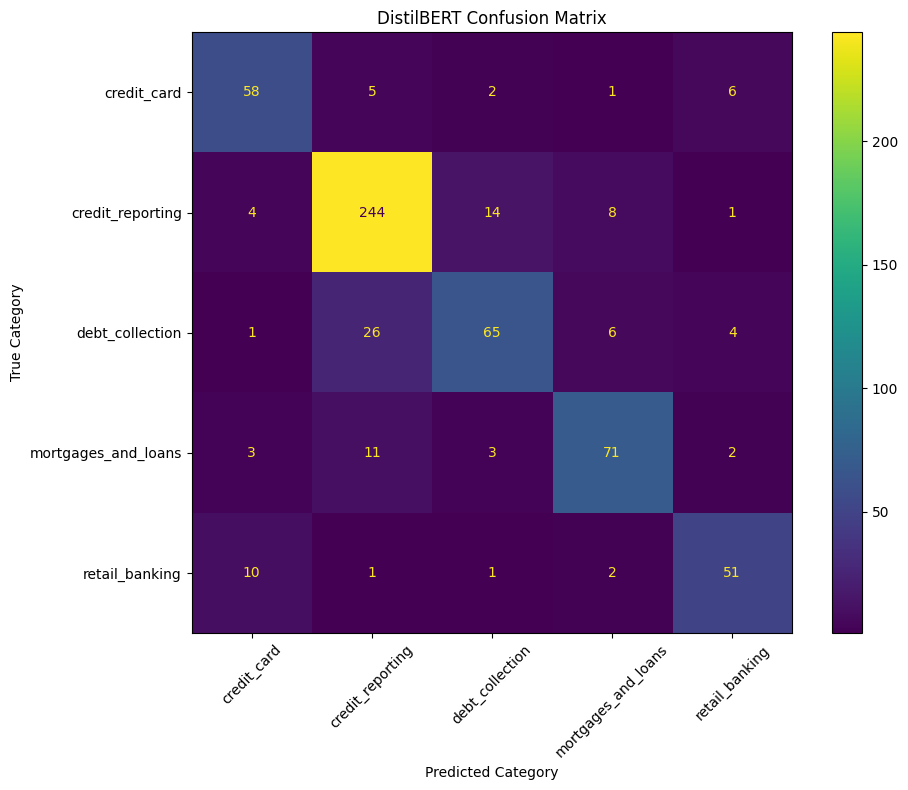

In [42]:
# Transformer Confusion Matrix

cm_transformer = confusion_matrix(
    test_labels,
    test_predictions,
    labels=range(len(categories))
)

fig, ax = plt.subplots(figsize=(10, 8))

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm_transformer,
    display_labels=categories
)

cm_display.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("DistilBERT Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.tight_layout()
plt.show()

In [43]:
transformer_error_df = test_df[
    ["text", "category", "label"]
].copy()

transformer_error_df["predicted_label"] = (
    test_predictions
)

transformer_error_df["predicted_category"] = (
    transformer_error_df["predicted_label"]
    .map(id2label)
)

transformer_error_df["Correct"] = (
    transformer_error_df["category"]
    ==
    transformer_error_df["predicted_category"]
)

display(
    transformer_error_df[
        [
            "text",
            "category",
            "predicted_category",
            "Correct"
        ]
    ].head(20)
)

,text,category,predicted_category,Correct
2489,transunion properly investigaed following item credit requested valaidation numberous time documenetaion sent unverified account,credit_reporting,credit_reporting,True
2232,daughter taken er year ago father signed check signed discharge year started getting contacted bill visit tried solve issue hospital sim...,debt_collection,credit_reporting,False
3374,disputed several account credit report open fraudently credit bureau also filed ftc report,credit_reporting,credit_reporting,True
137,paid debt went collection aldous associate term payment pay deletion aldous associate live end agreement report agreement credit bureau ...,debt_collection,debt_collection,True
89,sent check lowes credit card synchrony bank amount full amount due statement received email synchrony bank delinquent account charged la...,credit_card,credit_card,True
1929,hello name writing email file complaint lvnv dealing owe money company contract cancelled removed offof credit report name changed whoev...,credit_reporting,credit_reporting,True
480,experian requesting affidavit form sign notarize senior executive verifying signature willfully comply authorization furnished credit re...,credit_reporting,credit_reporting,True
916,received phone call called company ar account resolution service telling placed collection medical debt regarding previous visit son er ...,debt_collection,debt_collection,True
2886,u bank refused refund monies put escrow account insurance property provided documentation stating paying private company insurance addre...,mortgages_and_loans,retail_banking,False
3606,opened balance opened balanced account opened balanced account opned balanced,credit_reporting,credit_reporting,True


In [44]:
misclassified_transformer = transformer_error_df[
    transformer_error_df["Correct"] == False
]

print(
    "Number of misclassified complaints:",
    len(misclassified_transformer)
)

display(
    misclassified_transformer[
        [
            "text",
            "category",
            "predicted_category"
        ]
    ].head(20)
)

Number of misclassified complaints: 111


,text,category,predicted_category
2232,daughter taken er year ago father signed check signed discharge year started getting contacted bill visit tried solve issue hospital sim...,debt_collection,credit_reporting
2886,u bank refused refund monies put escrow account insurance property provided documentation stating paying private company insurance addre...,mortgages_and_loans,retail_banking
3224,bank debited account sent southeast toyota finance called finance company time told credited account woman named bank researched problem...,mortgages_and_loans,retail_banking
3253,chase bank closed account disputed claim card ending claim related acct received letter saying chase researched transaction agreed incor...,credit_card,retail_banking
3276,ordered mattress company opened klarna account help finance order called customer service spoke asked cancel order asked cancel klarna a...,credit_card,retail_banking
803,terminated contract company credit card company agreed review case determined company owe since given notice terminate properly previous...,debt_collection,credit_card
1876,covid job commission fell behind payment contact flagship entire time assured due covid would effect credit paid car credit score droppe...,mortgages_and_loans,credit_reporting
3197,got police report somebody stole identity,debt_collection,credit_reporting
2857,may concern cable service due company merger loss hour income could continue pay bill called inform let know would needing cancel servic...,debt_collection,credit_reporting
2682,massive fraud going related unemployment benefit never filed claim notified dc still employed yet received card benefit,credit_card,debt_collection


In [45]:
# Classical Logistic Regression metrics

lr_accuracy = accuracy_score(
    y_Test,
    y_pred
)

lr_precision, lr_recall, lr_f1, _ = (
    precision_recall_fscore_support(
        y_Test,
        y_pred,
        average="weighted",
        zero_division=0
    )
)

lr_macro_f1 = precision_recall_fscore_support(
    y_Test,
    y_pred,
    average="macro",
    zero_division=0
)[2]

print("Logistic Regression Results")
print("---------------------------")

print(f"Accuracy:          {lr_accuracy:.4f}")
print(f"Precision:         {lr_precision:.4f}")
print(f"Recall:            {lr_recall:.4f}")
print(f"Weighted F1:       {lr_f1:.4f}")
print(f"Macro F1:          {lr_macro_f1:.4f}")

Logistic Regression Results
---------------------------
Accuracy:          0.8342
Precision:         0.8546
Recall:            0.8342
Weighted F1:       0.8382
Macro F1:          0.8089


In [46]:
comparison_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "DistilBERT"
    ],

    "Accuracy": [
        lr_accuracy,
        transformer_accuracy
    ],

    "Precision": [
        lr_precision,
        transformer_precision
    ],

    "Recall": [
        lr_recall,
        transformer_recall
    ],

    "Weighted F1": [
        lr_f1,
        transformer_f1
    ],

    "Macro F1": [
        lr_macro_f1,
        transformer_macro_f1
    ]
})

display_table(
    comparison_results.round(4),
    title="Classical Model vs Transformer Comparison"
)

Classical Model vs Transformer Comparison


,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Logistic Regression,0.8342,0.8546,0.8342,0.8382,0.8089
1,DistilBERT,0.8150,0.8129,0.8150,0.8126,0.7884


In [47]:
# Measure Logistic Regression training time

start_time = time.time()

LR_model_comparison = Pipeline([
    (
        'vectorizer',
        TfidfVectorizer(ngram_range=(1,2))
    ),

    (
        'classifier',
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000
        )
    )
])

LR_model_comparison.fit(
    X_Train,
    y_Train
)

lr_training_time = time.time() - start_time

print(
    f"Logistic Regression training time: "
    f"{lr_training_time:.2f} seconds"
)

print(
    f"DistilBERT training time: "
    f"{transformer_training_time:.2f} seconds"
)

Logistic Regression training time: 190.33 seconds
DistilBERT training time: 113.91 seconds


In [48]:
training_time_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "DistilBERT"
    ],

    "Training Time (seconds)": [
        lr_training_time,
        transformer_training_time
    ]
})

display_table(
    training_time_comparison.round(2),
    title="Training Time Comparison"
)

Training Time Comparison


,Model,Training Time (seconds)
0,Logistic Regression,190.33
1,DistilBERT,113.91


In [49]:
# Count DistilBERT parameters

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("DistilBERT total parameters:", total_parameters)
print("DistilBERT trainable parameters:", trainable_parameters)

DistilBERT total parameters: 66957317
DistilBERT trainable parameters: 66957317


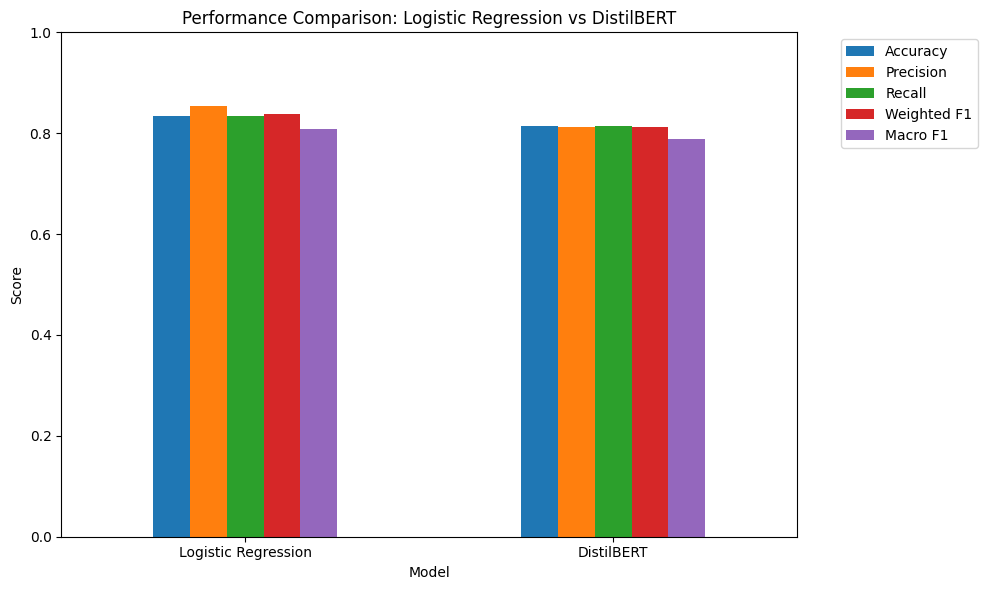

In [50]:
comparison_plot = comparison_results.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "Weighted F1",
        "Macro F1"
    ]
]

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Performance Comparison: Logistic Regression vs DistilBERT"
)

plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()